# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [3]:
import data

import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

What is the difference between artificial intelligence, machine learning and deep learning?

In [41]:
# Artificial intelligence is the broad term that includes machine learning and deep learning.

#Machine learning is a subset of AI that uses algorithms to learn from data

#Deep learning is a subset of Machine Learning that uses neural networks to learn complex patterns from data

What is a neural network?

In [43]:
#A method in AI that teaches computers to process data in a way that is similar to human processing

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [45]:
#Linear is a connected layer (taking 2 = size of input data, 50 = number of output features; number of neurons in this layer)

What does the activation function do?

In [47]:
#Sigmoid is activation function (applied to output of Linear layer --> squashes output of previous layer to a range between 0-1)
#It helps the neural network learn the boundaries of complex decisions so that it can create a natural/reasonable output

What is a loss function? Why do we need one?

In [49]:
loss_fn = torch.nn.MSELoss() #squared error, how far off predictions are

#A loss function quantifies the error margin between the model's prediction and the actual data (measures the model's performance)
#We need a loss function to figure out how accurate the model is, and to know how much to train the model

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [51]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#We call optimizer.zero_grad() first to reset the optimizer's gradients before computing new ones (a gradient indicates how much the loss function changes as the model's parameters are adjusted)
#Loss.backward() calculates the gradients of the loss function with respect to the parameters of the model (the calculations are passed through to update the model parameters through optmizer.step())

#If you call loss.backward() first it wouldn't calculate the correct gradients because they weren't resetted every cycle and so the model wouldn't be updated correctly

Iteration 0, Loss: 1.4362009763717651
Iteration 100, Loss: 0.97832190990448
Iteration 200, Loss: 0.9503216743469238
Iteration 300, Loss: 0.9031534194946289
Iteration 400, Loss: 0.830910861492157
Iteration 500, Loss: 0.7347508072853088
Iteration 600, Loss: 0.6294167637825012
Iteration 700, Loss: 0.5334082245826721
Iteration 800, Loss: 0.4589215815067291
Iteration 900, Loss: 0.40646857023239136


# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [53]:
#model = torch.nn.Sequential(
#    torch.nn.Linear(2, 50),
#    torch.nn.Sigmoid(),
#    torch.nn.Linear(50, 1)
#)

#Original
#torch.nn.Linear(2, 50),
#torch.nn.Linear(50, 1)

#Modified
#torch.nn.Linear(2, 30),
#torch.nn.Linear(30, 1)

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [55]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#Original: Iteration 900, Loss: 0.36069780588150024

#Modified: Iteration 900, Loss: 0.41571560502052307

#Higher loss --> Model's predictions are farther from actual data values (worse performance)

Iteration 0, Loss: 1.294199824333191
Iteration 100, Loss: 0.987667977809906
Iteration 200, Loss: 0.9674434065818787
Iteration 300, Loss: 0.9372524619102478
Iteration 400, Loss: 0.8946465849876404
Iteration 500, Loss: 0.8354233503341675
Iteration 600, Loss: 0.7556213140487671
Iteration 700, Loss: 0.6638233661651611
Iteration 800, Loss: 0.5740787386894226
Iteration 900, Loss: 0.49762365221977234


Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [57]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")


Iteration 0, Loss: 1.3874818086624146
Iteration 100, Loss: 0.870292067527771
Iteration 200, Loss: 0.7288496494293213
Iteration 300, Loss: 0.5791420340538025
Iteration 400, Loss: 0.4743156135082245
Iteration 500, Loss: 0.39854785799980164
Iteration 600, Loss: 0.338285356760025
Iteration 700, Loss: 0.30282559990882874
Iteration 800, Loss: 0.28318431973457336
Iteration 900, Loss: 0.27353668212890625


In [58]:
#Original: Iteration 900, Loss: 0.36069780588150024
#Modified: Iteration 900, Loss: 0.2857699990272522

#Lower loss --> better performance

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [60]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.8329519033432007
Iteration 100, Loss: 0.865181028842926
Iteration 200, Loss: 0.6889802813529968
Iteration 300, Loss: 0.5259472727775574
Iteration 400, Loss: 0.4083504378795624
Iteration 500, Loss: 0.3355228006839752
Iteration 600, Loss: 0.29003703594207764
Iteration 700, Loss: 0.2563563883304596
Iteration 800, Loss: 0.2290223091840744
Iteration 900, Loss: 0.20449517667293549


In [61]:
#Original: Iteration 900, Loss: 0.36069780588150024
#Modified: Iteration 900, Loss: 0.20629411935806274

#Lowest loss so far --> best performance

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [63]:
#Sigmoid is an S-shaped curve, good for probability output, is computationall expensive
#ReLU is a piecewise linear function, good for hidden layers in deep networks (data not shwon used byy the machine to learn complex patterns) and big inputs, computationally efficient
#TanH is the hyperbolic tangent function, good for cases where negative values need to be represented (e.g. stock prices), moderately computationally-demanding

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [65]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#Lower learning rate makes model more stable but slower

Iteration 0, Loss: 1.214652419090271
Iteration 100, Loss: 0.46724677085876465
Iteration 200, Loss: 0.271689772605896
Iteration 300, Loss: 0.1736273616552353
Iteration 400, Loss: 0.110969677567482
Iteration 500, Loss: 0.0829460471868515
Iteration 600, Loss: 0.0698741227388382
Iteration 700, Loss: 0.06298191845417023
Iteration 800, Loss: 0.05638280138373375
Iteration 900, Loss: 0.05047425255179405


In [66]:
#Original: Iteration 900, Loss: 0.36069780588150024
#Modified: Iteration 900, Loss: 0.04475950077176094

Modify your model to have **two hidden layers** instead of one. Give that code here.

In [68]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.0151023864746094
Iteration 100, Loss: 0.2889387905597687
Iteration 200, Loss: 0.1308307945728302
Iteration 300, Loss: 0.09591428935527802
Iteration 400, Loss: 0.08978613466024399
Iteration 500, Loss: 0.08216112852096558
Iteration 600, Loss: 0.07484792917966843
Iteration 700, Loss: 0.06546083092689514
Iteration 800, Loss: 0.0581715852022171
Iteration 900, Loss: 0.0533912293612957


# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [5]:
import caitlindata

Define a new model and train it **poorly** in the cell below.

In [53]:
model1 = torch.nn.Sequential(
    torch.nn.Linear(2, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-1)

for t in range(500):
    y_pred = model(caitlindata.x)
    loss = loss_fn(y_pred, caitlindata.y)
    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 7.969976425170898
Iteration 100, Loss: 8.582149505615234
Iteration 200, Loss: 8.19210433959961
Iteration 300, Loss: 8.068524360656738
Iteration 400, Loss: 8.023234367370605


Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

In [66]:
model2 = torch.nn.Sequential(
    torch.nn.Linear(2, 80),
    torch.nn.ReLU(),
    torch.nn.Linear(80, 80),
    torch.nn.ReLU(),
    torch.nn.Linear(80, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr = 1e-4)

for t in range(100000):
    y_pred = model2(caitlindata.x)
    loss = loss_fn(y_pred, caitlindata.y)

    #see if there's a nan issue
    if torch.isnan(loss).any():
        print(f"nan at iteration {t}")
        break

    optimizer.zero_grad()
    loss.backward()
    
    optimizer.step()

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 10.018397331237793
Iteration 100, Loss: 9.78590202331543
Iteration 200, Loss: 9.675469398498535
Iteration 300, Loss: 9.596875190734863
Iteration 400, Loss: 9.542122840881348
Iteration 500, Loss: 9.499767303466797
Iteration 600, Loss: 9.460165023803711
Iteration 700, Loss: 9.422218322753906
Iteration 800, Loss: 9.385729789733887
Iteration 900, Loss: 9.348794937133789
Iteration 1000, Loss: 9.313460350036621
Iteration 1100, Loss: 9.279268264770508
Iteration 1200, Loss: 9.24575424194336
Iteration 1300, Loss: 9.213889122009277
Iteration 1400, Loss: 9.180340766906738
Iteration 1500, Loss: 9.147110939025879
Iteration 1600, Loss: 9.115697860717773
Iteration 1700, Loss: 9.081372261047363
Iteration 1800, Loss: 9.048558235168457
Iteration 1900, Loss: 9.015694618225098
Iteration 2000, Loss: 8.983222961425781
Iteration 2100, Loss: 8.951375007629395
Iteration 2200, Loss: 8.919156074523926
Iteration 2300, Loss: 8.88827133178711
Iteration 2400, Loss: 8.858458518981934
Iteration 2500

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

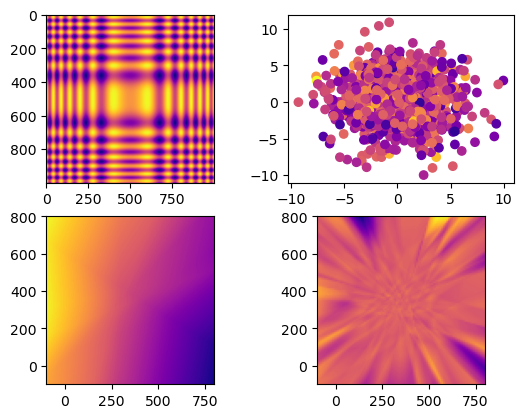

In [69]:
import matplotlib.pyplot as plt

new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output1 = model1(grid).detach()

output2 = model2(grid).detach()

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(caitlindata.pattern, cmap = "plasma")
ax[0, 1].scatter(caitlindata.x_values, caitlindata.y_values, c = caitlindata.color_values, cmap = "plasma")
ax[1, 0].imshow(output1, extent = (-100, 800, -100, 800), cmap = "plasma")
ax[1, 1].imshow(output2, extent = (-100, 800, -100, 800), cmap = "plasma")
plt.show()


# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [113]:
#Got data from:
#https://github.com/zalandoresearch/fashion-mnist

import torch.nn as nn
import torch.optim as optim
import torchvision #contains the dataset i want to use
import torchvision.transforms as transforms 

#define what the transformation is (convert data format)
transform = transforms.Compose([ 
    transforms.ToTensor(), #convert the numpy.ndarray to tensor (multi dimensional array?)
])

#get the training dataset "train"
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)

#get the testing dataset "t10k"
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

#dataloader for data; batching up the data into groups of 64 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True) #shuffle the clothing types so that ai learns to recognize different classes
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

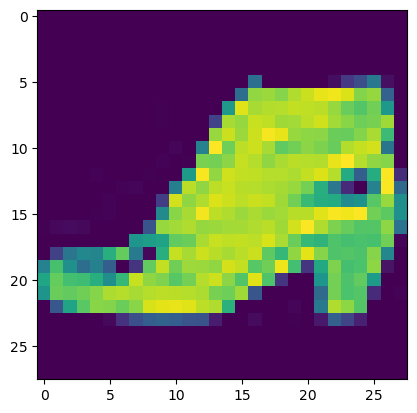

Label: Ankle boot


In [126]:
#class labels
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

#shuffle some images from the training dataset (shuffled)
def imshow(img):
    img = img / 2.5  # unnormalize
    plt.imshow(img.squeeze())
    plt.show()

images, labels = next(iter(train_loader))
imshow(images[0])

print(f"Label: {classes[labels[0]]}")

#have to build convolutional neural network instead of nn bc it is images. i don't want to do that

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!